# Sea Ice Concentration Algorithms

By the end of this notebook, you should be able to:
- Explain the conceptual basis of the NASA Team and Bootstrap sea ice algorithms.

## 11. Passive Microwave Sea Ice Algorithms

Sea ice algorithms convert measured brightness temperatures into estimates of sea ice concentration and sometimes ice type or age.

Two commonly discussed algorithm families are:

1. **NASA Team algorithm**  
   Uses ratios of brightness temperature differences, especially polarization and gradient ratios.

2. **NASA Bootstrap algorithm**  
   Uses the magnitude and distribution of brightness temperatures and interpolates between open-water and ice tie points.

Both approaches rely on the fact that open water and sea ice occupy different regions of brightness-temperature space.

## 12. NASA Team Algorithm: Polarization and Gradient Ratios

The NASA Team approach commonly uses two ratios:

\[
PR = \frac{T_{B,19V} - T_{B,19H}}{T_{B,19V} + T_{B,19H}}
\]

\[
GR = \frac{T_{B,37V} - T_{B,19V}}{T_{B,37V} + T_{B,19V}}
\]

where $PR$ is a polarization ratio and $GR$ is a gradient ratio.

The central idea is to compute these ratios for a satellite pixel and compare the result to expected values for open water, first-year ice, and multi-year ice. In practice, weather filters are used because water vapor and atmospheric emission can cause noise near the ice edge.

In [10]:
def polarization_ratio(T19V, T19H):
    return (T19V - T19H) / (T19V + T19H)

def gradient_ratio(T37V, T19V):
    return (T37V - T19V) / (T37V + T19V)

examples['PR'] = polarization_ratio(examples['T19V'], examples['T19H'])
examples['GR'] = gradient_ratio(examples['T37V'], examples['T19V'])
examples[['surface', 'PR', 'GR']]

,surface,PR,GR
0,Open water,0.250000,0.047619
1,First-year ice,0.030928,-0.004016
2,Multi-year ice,0.035294,-0.060241


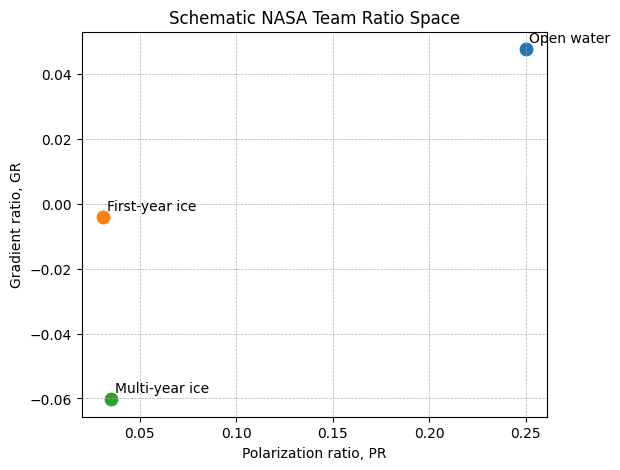

In [11]:
plt.figure(figsize=(6, 5))
for _, row in examples.iterrows():
    plt.scatter(row['PR'], row['GR'], s=80)
    plt.text(row['PR'] + 0.002, row['GR'] + 0.002, row['surface'])
plt.xlabel('Polarization ratio, PR')
plt.ylabel('Gradient ratio, GR')
plt.title('Schematic NASA Team Ratio Space')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

### Limitations of the NASA Team Approach

Retrievals can be more uncertain when atmospheric or surface conditions make sea ice look more like open water. Common problem cases include:

- Spring and summer melt ponds
- Atmospheric water vapor near the ice edge
- Thin, newly formed ice
- Mixed pixels containing both ice and open water
- Surface wetness when air temperature is above freezing

These conditions tend to matter most near the ice edge or during melt season.

## 13. NASA Bootstrap Algorithm: Interpolation Between Tie Points

The Bootstrap approach estimates sea ice concentration by comparing observed brightness temperatures to open-water and 100% ice reference values, often called **tie points**.

In a simplified one-dimensional version:

\[
C = \frac{T_B - T_{B,water}}{T_{B,ice} - T_{B,water}}
\]

where $C$ is concentration. Values are then constrained to the physical range from 0 to 1.

The real Bootstrap algorithm uses multi-dimensional brightness temperature spaces and tie points that can vary by date, region, sensor, and atmospheric condition.

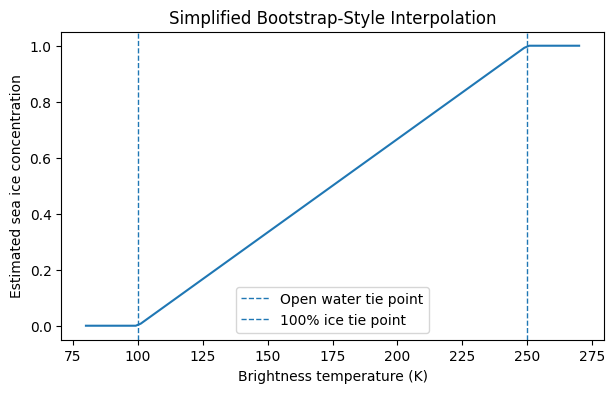

In [12]:
def bootstrap_concentration(TB, TB_water=100, TB_ice=250):
    C = (TB - TB_water) / (TB_ice - TB_water)
    return np.clip(C, 0, 1)

TB_values = np.linspace(80, 270, 100)
C_values = bootstrap_concentration(TB_values)

plt.figure(figsize=(7, 4))
plt.plot(TB_values, C_values)
plt.axvline(100, linestyle='--', linewidth=1, label='Open water tie point')
plt.axvline(250, linestyle='--', linewidth=1, label='100% ice tie point')
plt.xlabel('Brightness temperature (K)')
plt.ylabel('Estimated sea ice concentration')
plt.title('Simplified Bootstrap-Style Interpolation')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

In [13]:
observed_TB = np.array([100, 130, 175, 220, 250])
estimated_C = bootstrap_concentration(observed_TB)

pd.DataFrame({
    'observed_TB_K': observed_TB,
    'estimated_concentration': estimated_C,
    'estimated_concentration_percent': estimated_C * 100
})

,observed_TB_K,estimated_concentration,estimated_concentration_percent
0,100,0.0,0.0
1,130,0.2,20.0
2,175,0.5,50.0
3,220,0.8,80.0
4,250,1.0,100.0


### Bootstrap Near and Away from the Ice Edge

Near the ice edge, Bootstrap-style methods are useful because brightness temperatures can be interpolated between open water and 100% ice conditions.

Away from the ice edge, additional channels such as 37V and 37H can help distinguish first-year and multi-year ice because those ice types have different microwave emissivities and scattering behavior.

## 14. Common Error Sources

Passive microwave sea ice algorithms are most reliable when the signal is clear, such as in high-concentration pack ice or open ocean. Errors are typically largest where surface conditions are mixed or changing quickly.

Important sources of uncertainty include:

- Mixed pixels near the ice edge
- Thin ice and newly formed ice
- Melt ponds and wet snow
- Atmospheric water vapor and clouds, especially at high frequencies
- Surface roughness and snow cover
- Sensor differences and intercalibration across the multi-decadal record

Because of these uncertainties, different sea ice products may not agree exactly, especially during melt season or near the ice edge.

## 15. A Conceptual Seasonal Sea Ice Cycle

Sea ice extent has a strong seasonal cycle. Arctic sea ice typically reaches a maximum near the end of winter and a minimum near the end of summer. Antarctic sea ice also has a strong seasonal cycle, but the geography and ocean setting are different.

The example below is not observational data. It is a simple schematic showing how a seasonal cycle can be combined with a long-term trend.

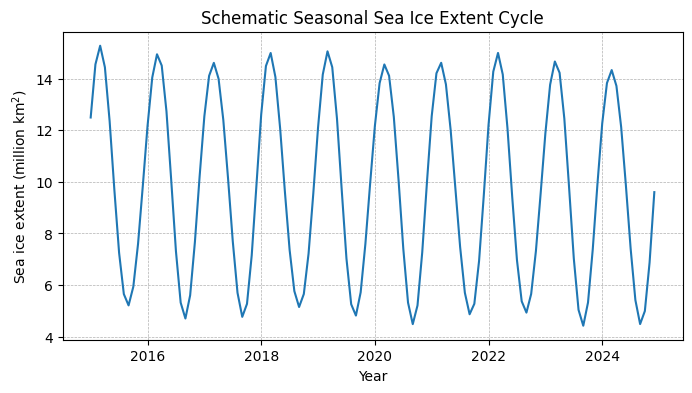

In [14]:
months = np.arange(0, 12 * 10)  # 10 years of monthly values
seasonal_cycle = 10 + 5 * np.cos(2 * np.pi * (months - 2) / 12)
trend = -0.04 * months / 12
noise = 0.3 * np.sin(2 * np.pi * months / 7)
extent_million_km2 = seasonal_cycle + trend + noise

time_years = 2015 + months / 12

plt.figure(figsize=(8, 4))
plt.plot(time_years, extent_million_km2)
plt.xlabel('Year')
plt.ylabel('Sea ice extent (million km$^2$)')
plt.title('Schematic Seasonal Sea Ice Extent Cycle')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## 16. Check Your Understanding

1. Why are passive microwave sensors useful for sea ice monitoring during polar night?
2. What is the difference between sea ice concentration and sea ice extent?
3. Why can first-year and multi-year sea ice have different microwave signatures?
4. What is polarization, and why does the difference between V and H polarization help identify surface type?
5. Why are sea ice retrievals often more uncertain near the ice edge?
6. In the simplified Bootstrap example, what concentration would you estimate for a brightness temperature halfway between the open-water and 100% ice tie points?

## 17. Key Takeaways

- Passive microwave observations provide the backbone of the multi-decadal satellite sea ice record.
- Sea ice concentration is derived from differences in microwave brightness temperature between open water and ice.
- Emissivity, polarization, and frequency dependence are central to passive microwave sea ice retrievals.
- First-year and multi-year ice differ physically and electromagnetically.
- The NASA Team algorithm uses ratios of brightness temperatures, while the Bootstrap algorithm relies more directly on brightness temperature magnitudes and tie points.
- Retrieval uncertainty is largest near the ice edge, during melt season, and where thin ice, melt ponds, weather, or mixed pixels complicate the signal.